# Image single-cell analysis

In this tutorial I will show you how to perform quality control on your image processing and segmentation results.  
This tutorial assumes that you have already processed and quantified your images, and thus you have a quantification matrix.  
For information to how to get here from raw images go to the image processing section.

## Import necesary packages and data

In [1]:
#lets take a quick look
import skimage.io as io
import numpy as np
import opendvp as dvp

import napari
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd

/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Let's download the demo data

In [ ]:
url = "https://zenodo.org/records/15830141/files/data.tar.gz?download=1"
output_path = "demodata.gz"  

import requests
response = requests.get(url, stream=True)
response.raise_for_status()

with open(output_path, "wb") as f:
    for chunk in response.iter_content(chunk_size=8192):
        if chunk:
            f.write(chunk)

print(f"Download complete: {output_path}")

Now you have to decompress it

## Part 1: Visualize segmentation

First step is to ensure that the segmentation is good enough. Cell segmentation is a critical step and it must be controlled.   
QuPath is a great piece of software created to allow users to see their images in a smooth manner.  
However QuPath is usually not happy with us dropping a .tif mask into it.. Therefore, openDVP has utilities for translating a standard segmentation mask into QuPath compatible shapes, these shapes also allow you to continue part of your analysis in QuPath if you want.

In [2]:
# let's perform some quick QC
path_to_segmentation = "data/segmentation/segmentation_mask.tif"
seg = io.imread(path_to_segmentation)

In [3]:
print(f"Number of pixels in x,y: {seg.shape}")
print(f"Number of segmented objects {np.unique(seg).size -1}")

Number of pixels in x,y: (5000, 5000)
Number of segmented objects 16808


/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_33694/2237838827.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(seg, vmax=1)


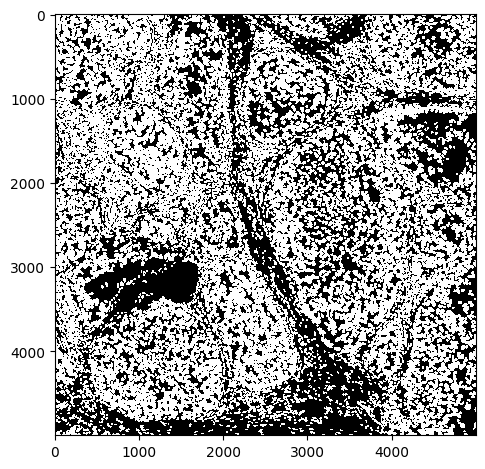

In [4]:
#quick look
io.imshow(seg, vmax=1)

/var/folders/x7/grkjlk8s223dy6234rnz1885mxz2_6/T/ipykernel_33694/1375747239.py:2: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  io.imshow(seg[:500,:500])
/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/skimage/io/_plugins/matplotlib_plugin.py:158: UserWarning: Low image data range; displaying image with stretched contrast.
  lo, hi, cmap = _get_display_range(image)


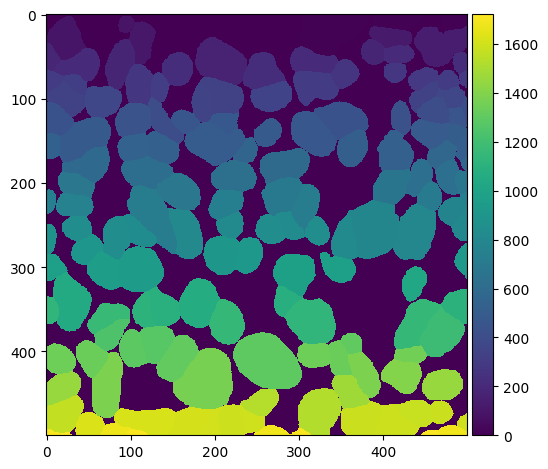

In [5]:
# we can zoom in to check
io.imshow(seg[:500,:500])

You could plot and check various regions of the tissue, and overlay with the image, but this starts to get bulky and slow. We recommend an interactive session where one can zoom in and out, and check different channels.

### Visualize interactively in QuPath

Now let's transform this into polygons that QuPath can digest

In [6]:
# transform mask into a geodataframe containing the polygons
gdf = dvp.io.segmask_to_qupath(path_to_segmentation, simplify_value=1, save_as_detection=True)
gdf.head()

/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


INFO     no axes information specified in the object, setting `dims` to: ('y', 'x')                                


/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution


16:13:05.55 | INFO | Simplifying the geometry with tolerance 1


,geometry,objectType
label,,
1,"POLYGON ((60 43.5, 54 43.5, 46.5 39, 42.5 30, ...",detection
2,"POLYGON ((134 19.5, 129 19.5, 126 15.5, 119 11...",detection
3,"POLYGON ((167 31.5, 148 33.5, 142 30.5, 137.5 ...",detection
4,"POLYGON ((188 13.5, 178 13.5, 167 7.5, 160.5 1...",detection
5,"POLYGON ((235 48.5, 231 47.5, 220 39.5, 202.5 ...",detection


In [7]:
# now lets write that geodataframe into a file
gdf.to_file("outputs/segmentation_for_qupath.geojson")

/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


Now open QuPath, drag the image into it, and then draft that .geojson file, you should be able to see the shapes :)

<img src="../_static/mIF_seg.png" alt="viz_segmentation_in_qupath" width="600px" />

### Visualize interactively in Napari

In [8]:
#load image
image = io.imread("data/image/mIF.ome.tif")

In [9]:
# this should produce a napari window with image and segmentation mask
viewer = napari.Viewer()
viewer.add_image(image, name="mIF_image")
viewer.add_labels(seg, name='Segmentation')

<Labels layer 'Segmentation' at 0x315445e50>

Napari is a great python-based software that keeps getting better. It has a little learning curve, I suggest you check [Loading multichannel images](https://napari.org/stable/howtos/layers/image.html#loading-multichannel-images) for more details of image controls and check this [Segmentation masks info](https://napari.org/stable/howtos/layers/labels.html#creating-deleting-merging-and-splitting-connected-components).

## Part 2: Analyze the single cell data

openDVP follows the guidelines of the scverse ecosystem for the most replicable and interoperable data formats and functions python can offer life scientists and bioinformaticians.  
A big part is using [AnnData](https://anndata.readthedocs.io/en/stable/), a really nice data object that stores data and its metadata all together.  
For life scientists it also means you could use functions already created by very popular and well-maintained packages, like [Scanpy](https://scanpy.readthedocs.io/en/1.10.x/index.html).

In [10]:
#transform the .csv matrix to an AnnData object
adata = dvp.io.quant_to_adata("data/quantification/quant.csv")

16:13:11.75 | INFO | Detected 0 in 'CellID' — shifting all values by +1 for 1-based indexing.
16:13:11.75 | INFO |  16808 cells and 15 variables


adata is composed of three main compartments:  
1. X , which stores all the numerical data
2. adata.obs, which stores all the metadata of the observations (here X,Y coordinates, morphological features)
3. adata.var, which stores all the metadata for the variables, aka the markers

In [11]:
#chech first 25 values of adata.X
adata.X[:5,:5]

array([[ 5.70393701,  7.23228346,  5.71811024, 29.96377953, 21.42992126],
       [ 5.53472222,  6.14583333,  4.83159722, 23.3125    , 13.00520833],
       [ 5.56097561,  6.38922764,  4.97764228, 24.02845528, 15.96341463],
       [ 5.52616279,  6.00581395,  4.74127907, 21.62209302, 10.7122093 ],
       [ 5.5971564 ,  6.38125329,  5.00105319, 24.71879937, 22.37651395]])

In [12]:
# cell metadata
adata.obs.head()

,CellID,Y_centroid,X_centroid,Area,MajorAxisLength,MinorAxisLength,Eccentricity,Orientation,Extent,Solidity
0,1,17.612598,53.337008,1270.0,48.198269,36.841132,0.644782,0.359469,146.669048,0.949178
1,2,6.598958,126.006944,576.0,45.835698,18.372329,0.916152,1.513685,113.112698,0.886154
2,3,17.416667,156.656504,984.0,40.751104,31.700565,0.628380,-1.528462,121.396970,0.955340
3,4,4.982558,179.337209,344.0,34.620290,13.577757,0.919884,1.474818,82.627417,0.971751
4,5,19.159558,228.598210,1899.0,54.446578,49.053930,0.433912,1.287374,196.610173,0.896601


In [13]:
# variable metadata, now empty
adata.var.head()

""
mean_750_bg
mean_647_bg
mean_555_bg
mean_488_bg
mean_DAPI_bg


### Filter cells by Area

In [14]:
# filter cells that are too big or too small
adata = dvp.tl.filter_by_abs_value(
    adata=adata, feature_name="Area", 
    lower_bound=0.01, upper_bound=0.99, mode="quantile")

16:13:11.84 | INFO | Starting filter_by_abs_value for feature 'Area'...
16:13:11.84 | INFO | Feature 'Area' identified from adata.obs.
16:13:11.84 | INFO | Keeping cells with 'Area' >= 295.0000 (from quantile bound: 0.01).
16:13:11.84 | INFO | Keeping cells with 'Area' <= 2376.4400 (from quantile bound: 0.99).
16:13:11.84 | SUCCESS | 16475 of 16808 cells (98.02%) passed the filter.
16:13:11.84 | INFO | New boolean column 'Area_filter' added to adata.obs.


In [15]:
# this column has now been added to adata.obs
adata.obs[["CellID","Area_filter"]].head()

,CellID,Area_filter
0,1,True
1,2,True
2,3,True
3,4,True
4,5,True


In [16]:
# we see that 333 cells have been labelled as not passing the filter
adata.obs.Area_filter.value_counts()

Area_filter
True     16475
False      333
Name: count, dtype: int64

Filtering here does not actually filter the dataset. We just added a column to the adata.obs that describes the status of cells relative to that filter. This is important because then we should check what cells are going to be filtered out, and we can add all the filters we prefer and then filter the dataset based on the desired filters. 

### Filter by initial nuclear stain signal

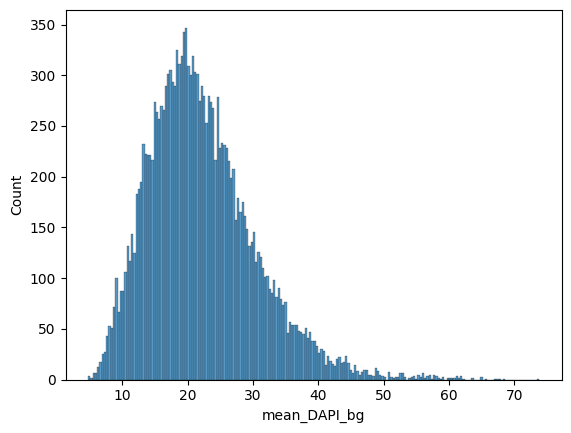

In [17]:
# let's check the nuclear stain distribution
df = pd.DataFrame(data=adata.X, columns=adata.var_names)
sns.histplot(data=df, x="mean_DAPI_bg", bins=200)
plt.show()

In [18]:
#based on that we can filter out dataset by absolute values
adata = dvp.tl.filter_by_abs_value(
    adata=adata,feature_name="mean_DAPI_bg", lower_bound=5, upper_bound=60, mode="absolute")

16:13:12.15 | INFO | Starting filter_by_abs_value for feature 'mean_DAPI_bg'...
16:13:12.16 | INFO | Feature 'mean_DAPI_bg' identified from adata.X.
16:13:12.16 | INFO | Keeping cells with 'mean_DAPI_bg' >= 5.0000 (from absolute bound: 5).
16:13:12.16 | INFO | Keeping cells with 'mean_DAPI_bg' <= 60.0000 (from absolute bound: 60).
16:13:12.16 | SUCCESS | 16777 of 16808 cells (99.82%) passed the filter.
16:13:12.16 | INFO | New boolean column 'mean_DAPI_bg_filter' added to adata.obs.


### Filter by ratio of nuclear stain between last and first DAPI images

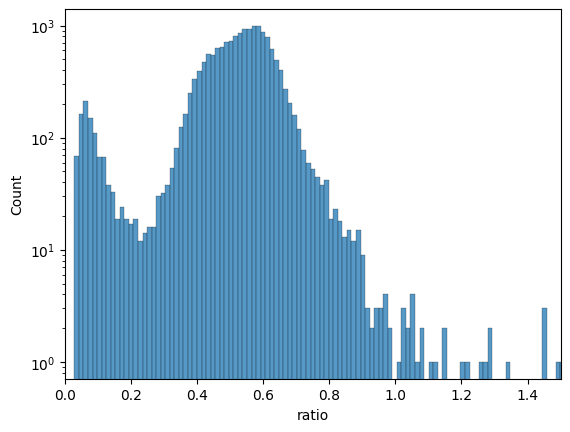

In [19]:
#let's check the ratio between first and last cycle
df = pd.DataFrame(data=adata.X, columns=adata.var_names)
df['ratio'] = df['mean_DAPI_2'] / df['mean_DAPI_bg']

fig,ax = plt.subplots()
sns.histplot(data=df, x="ratio", bins=200, ax=ax)
ax.set_xlim(0,1.5)
ax.set_yscale('log')

In [20]:
# based on that histogram we see
# many cells lost almost all their nuclear stain signal
adata = dvp.tl.filter_by_ratio(
    adata=adata, end_cycle="mean_DAPI_2", start_cycle="mean_DAPI_bg", 
    label="DAPI", min_ratio=0.25, max_ratio=1.05)

16:13:12.40 | INFO | Starting filter_by_ratio...
16:13:12.40 | INFO | Number of cells with DAPI ratio < 0.25: 1035
16:13:12.40 | INFO | Number of cells with DAPI ratio > 1.05: 28
16:13:12.40 | INFO | Cells with DAPI ratio between 0.25 and 1.05: 15745
16:13:12.40 | INFO | Cells filtered: 6.32%
16:13:12.40 | SUCCESS | filter_by_ratio complete.
16:13:12.40 | INFO | New boolean column 'DAPI_ratio_pass' added to adata.obs.


### Filter by manual annotations

Annotations should be made in QuPath, and classified by functionality.  
This means that you should create a QuPath Annotation Class for each different kind of ROI. 

In [21]:
#check annotations
gdf = gpd.read_file("data/manual_artefact_annotations/artefacts.geojson")

In [22]:
# here we see how the shapes look like
gdf.head()

,id,objectType,classification,geometry
0,9dbac0eb-6171-4da8-9c3f-846ecdb81dfb,annotation,"{ ""name"": ""folded_tissue"", ""color"": [ 176, 102...","POLYGON ((722 2645, 702 2647, 689.93 2650.81, ..."
1,cc4df5d0-fe6b-4285-849a-698851827e9c,annotation,"{ ""name"": ""Antibody_clumps"", ""color"": [ 32, 19...","POLYGON ((4685 2530, 4682 2531, 4677 2531, 467..."
2,e6aaf657-f4e7-401f-834b-a2fd5a072300,annotation,"{ ""name"": ""folded_tissue"", ""color"": [ 176, 102...","POLYGON ((3127 3675, 3119 3676, 3116 3677, 311..."
3,be635097-4631-46e7-b1a8-878363184124,annotation,"{ ""name"": ""CD8_noise"", ""color"": [ 51, 236, 220...","POLYGON ((117 3008, 110 3009.62, 105 3010, 96...."
4,baff029c-3349-4fa2-946a-0f5e55c46dc8,annotation,"{ ""name"": ""Antibody_clumps"", ""color"": [ 32, 19...","POLYGON ((3987 4058, 3984 4059, 3979 4059, 397..."


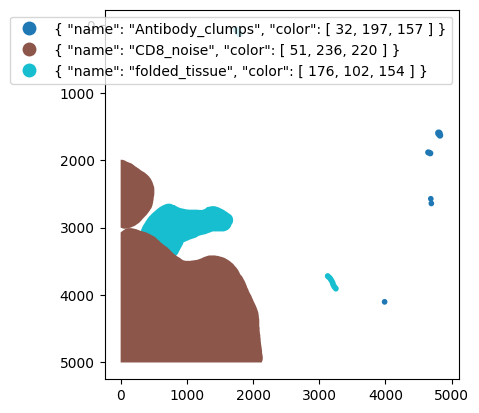

In [23]:
# lets plot those shapes and color them by class
fig,ax = plt.subplots()
gdf.plot(column="classification", legend=True, figsize=(8, 6), ax=ax)
ax.invert_yaxis()
plt.show()

In [24]:
adata = dvp.tl.filter_by_annotation(
    adata=adata, 
    path_to_geojson="data/manual_artefact_annotations/artefacts.geojson")

16:13:12.50 | INFO |  Each class of annotation will be a different column in adata.obs
16:13:12.50 | INFO |  TRUE means cell was inside annotation, FALSE means cell not in annotation
16:13:12.51 | INFO | GeoJSON loaded, detected: 10 annotations


In [25]:
# show the new columns
# for each annotation class there is a True/False column
# True means cell is inside shape, False means cell is outside shape
# ANY means the cell is at least in one shape
# annotation column shows name of annotation class
adata.obs.iloc[:, -5:]

,Antibody_clumps,CD8_noise,folded_tissue,ANY,annotation
0,False,False,False,False,Unannotated
1,False,False,False,False,Unannotated
2,False,False,False,False,Unannotated
3,False,False,False,False,Unannotated
4,False,False,False,False,Unannotated
...,...,...,...,...,...
16803,False,True,False,True,CD8_noise
16804,False,True,False,True,CD8_noise
16805,False,True,False,True,CD8_noise
16806,False,True,False,True,CD8_noise


Now that we have a well labelled dataset we can filter out cells we consider not good enough.  
We will remove cells found inside "Antibody_clumps" and "folded_tissue".  
(These have squigly lines up front because of the flipped True/False status).  

In [26]:
# new processed adata
adata_processed = adata[
    (adata.obs["Area_filter"])
    & (adata.obs["DAPI_ratio_pass"])
    & (~adata.obs["Antibody_clumps"])
    & (~adata.obs["folded_tissue"])
].copy() # type: ignore

/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


As you might have seen from plotting the labels, we can see that a large area of the imaged tissue has been labelled as CD8 noise.  
This kind of artefacts can happen.  
The simplest solution is to reduce the marker specific signal for cells present in those annotations, so-called marker imputation.  
(any better solutions are welcome!)

In [27]:
adata_processed = dvp.pp.impute_marker_with_annotation(
    adata=adata_processed,
    target_variable="mean_CD8", 
    target_annotation_column="CD8_noise",
    quantile_for_imputation=0.15
    )

16:13:12.58 | INFO | Imputing with 0.15% percentile value = 7.545454545454546


### QuPath QC

In [28]:
gdf = gpd.read_file("outputs/segmentation_for_qupath.geojson")
gdf.head()

,label,objectType,geometry
0,1,detection,"POLYGON ((60 43.5, 54 43.5, 46.5 39, 42.5 30, ..."
1,2,detection,"POLYGON ((134 19.5, 129 19.5, 126 15.5, 119 11..."
2,3,detection,"POLYGON ((167 31.5, 148 33.5, 142 30.5, 137.5 ..."
3,4,detection,"POLYGON ((188 13.5, 178 13.5, 167 7.5, 160.5 1..."
4,5,detection,"POLYGON ((235 48.5, 231 47.5, 220 39.5, 202.5 ..."


In [29]:
# check processed cells in qupath
# this will create a geodataframe from the processed adata, with only the good cells
cells = dvp.io.adata_to_qupath(
    adata=adata_processed, 
    geodataframe=gdf,
    adataobs_on="CellID",
    gdf_on="label",
    classify_by=None,
    simplify_value=None,
    save_as_detection=True)

16:13:12.90 | INFO | Found 15244 matching IDs between adata.obs['CellID'] and geodataframe['label'].


In [30]:
# let's save the file to drag it into qupath
cells.to_file("outputs/filtered_cells.geojson")

Napari QC not quite possible without spatialdata object, check tutorial #3 for more details

## Phenotype the cells

Clustering of cells from imaging data can be challenging. The simplest approach is to perform unsupervised clustering algorithms like k-means, louvain, or leiden. Despite their effectiveness in scRNAseq data, the data from multiplex imaging is noisier and struggles to cluster properly.  
Therefore, we use a supervised approach.
There are many elaborate approaches to phenotype your cells, machine learning algorithms, train your own XGBoost model, etc. We instead suggest we start with a simple approach with clear tradeoffs. 
We will use SCIMAP phenotyping.

Phenotying cells with scimap requires 3 steps:  
1. Import manually assigned thresholds (1 per marker)
2. Rescale dataset with thresholds to help algorithm assign phenotypes
3. Phenotype cells

Unfortunately, as of 08.07.2025, installing scimap and opendvp together is not possible.  
Therefore for steps 2,3 opendvp provides a wrapper of scimap functions.

### Import manually assigned thresholds

In [31]:
# this function loads and processes the values ready for the phenotyping
thresholds = dvp.io.import_thresholds(gates_csv_path="data/phenotyping/gates.csv")
thresholds

16:13:13.29 | INFO | Filtering out all rows with value 0.0 (assuming not gated)
16:13:13.29 | INFO | Found 8 valid gates
16:13:13.29 | INFO | Markers found: ['mean_Vimentin' 'mean_CD3e' 'mean_panCK' 'mean_CD8' 'mean_COL1A1'
 'mean_CD20' 'mean_CD68' 'mean_Ki67']
16:13:13.29 | INFO | Samples found: ['TD_15_TNBC_subset']
16:13:13.30 | INFO | Applying log1p transformation to gate values and formatting for scimap.
16:13:13.30 | INFO |    Output DataFrame columns: ['markers', 'TD_15_TNBC_subset']


,markers,TD_15_TNBC_subset
5,mean_Vimentin,1.915886
6,mean_CD3e,2.138796
7,mean_panCK,1.287972
8,mean_CD8,2.890372
10,mean_COL1A1,3.169333
11,mean_CD20,3.205329
12,mean_CD68,1.436576
13,mean_Ki67,1.093354


### Get adata ready for phenotyping 

In [32]:
# here we subset the adata object
# so that it only has the the markers mentioned in the imported threholds
# we also label all observations in that adata, with the sample_id
adata_phenotyping = adata_processed[:,adata_processed.var_names.isin(thresholds['markers'])].copy()
adata_phenotyping.obs['sample_id'] = "TD_15_TNBC_subset"

### Rescale data based on thresholds

In [33]:
# seems that I will have to:
# create adata for gating by filtering unused columns
adata_rescaled = dvp.pp.rescale(
                        adata=adata_phenotyping,
                        gate=thresholds,
                        method="all",
                        imageid="sample_id"
                        )


Scaling Image: TD_15_TNBC_subset
Scaling mean_Vimentin (gate: 1.916)
Scaling mean_CD3e (gate: 2.139)
Scaling mean_panCK (gate: 1.288)
Scaling mean_CD8 (gate: 2.890)
Scaling mean_COL1A1 (gate: 3.169)
Scaling mean_CD20 (gate: 3.205)
Scaling mean_CD68 (gate: 1.437)
Scaling mean_Ki67 (gate: 1.093)


/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/src/opendvp/pp/rescale.py:145: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  gate_mapping['gate'] = gate_mapping['gate'].fillna(gate_mapping['m_gate'])


### Phenotype cells

In [34]:
# we must load the phenotyping workflow
# this is the set of biological knowledge we have about the markers
# and what they mean to classify the cells
phenotype = pd.read_csv('data/phenotyping/celltype_matrix.csv')
# this just shows you the table 
phenotype.style.format(na_rep='')

,Unnamed: 0,Unnamed: 1,Vimentin,CD3e,panCK,CD8,COL1A1,CD20,CD68,Ki67
0,all,Epithelial,,,pos,,,,,
1,all,Mesenchymal,pos,,,,,,,
2,all,Immune,,anypos,,anypos,,anypos,anypos,
3,all,Fibroblasts,,,,,pos,,,
4,Immune,CD4_T_cell,,pos,,neg,,,,
5,Immune,CD8_T_cell,,,,pos,,,,
6,Immune,B_cell,,,,,,pos,,
7,Immune,Macrophage,,,,,,,pos,


In [35]:
# here we rename the variables to match the celltype_matrix.csv column names
# we remove the "mean_" part from "mean_CD8", resulting in "CD8", for each marker.
adata_phenotyping.var['feature_name']  = [name.split("_")[1] for name in adata_phenotyping.var_names]
# here we make it the index
adata_phenotyping.var.index = adata_phenotyping.var['feature_name'].values

# we did not do this before, because the thresholds dataframe had the previous names

In [36]:
adata_phenotyped = dvp.tl.scimap_phenotype(
    adata_phenotyping, 
    phenotype=phenotype, 
    label="phenotype",
    verbose=True) 

Phenotyping Epithelial
Phenotyping Mesenchymal
Phenotyping Immune
Phenotyping Fibroblasts
-- Subsetting Immune
Phenotyping CD4_T_cell
Phenotyping CD8_T_cell
Phenotyping B_cell
Phenotyping Macrophage
Consolidating the phenotypes across all groups


/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/src/opendvp/tl/scimap_phenotype.py:290: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  phenotype_labels_Consolidated = phenotype_labels.fillna(method='ffill', axis = 1)
/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/src/opendvp/tl/scimap_phenotype.py:290: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  phenotype_labels_Consolidated = phenotype_labels.fillna(method='ffill', axis = 1)


In [37]:
# lets check the results
adata_phenotyped.obs.phenotype.value_counts()

phenotype
Epithelial     7141
Unknown        3598
CD4_T_cell     2874
Fibroblasts     752
Mesenchymal     589
CD8_T_cell      165
B_cell          109
Macrophage       16
Name: count, dtype: int64

In [38]:
# lets transfer those phenotype labels and image label to our original adata_processed
adata_processed.obs['phenotype'] = adata_phenotyped.obs['phenotype'].copy()
adata_processed.obs['sample_id'] = "TD_15_TNBC_subset"

### Quality control of phenotypes using QuPath

In [39]:
gdf.head()

,label,objectType,geometry
0,1,detection,"POLYGON ((60 43.5, 54 43.5, 46.5 39, 42.5 30, ..."
1,2,detection,"POLYGON ((134 19.5, 129 19.5, 126 15.5, 119 11..."
2,3,detection,"POLYGON ((167 31.5, 148 33.5, 142 30.5, 137.5 ..."
3,4,detection,"POLYGON ((188 13.5, 178 13.5, 167 7.5, 160.5 1..."
4,5,detection,"POLYGON ((235 48.5, 231 47.5, 220 39.5, 202.5 ..."


In [40]:
# Let's create a geodataframe with cell segmentation, classified and coloured by phenotype
phenotypes = dvp.io.adata_to_qupath(
    adata=adata_processed, 
    geodataframe=gdf,
    adataobs_on="CellID",
    gdf_on="label",
    classify_by="phenotype",
    simplify_value=None,)

16:13:13.71 | WARNING | phenotype is not a categorical, converting to categorical
16:13:13.72 | INFO | Found 15244 matching IDs between adata.obs['CellID'] and geodataframe['label'].
16:13:13.72 | INFO | Classes now in shapes: ['Epithelial' 'Unknown' 'CD4_T_cell' 'Mesenchymal' 'Fibroblasts'
 'CD8_T_cell' 'Macrophage' 'B_cell']
16:13:13.72 | INFO | Parsing colors compatible with QuPath
16:13:13.72 | INFO | No color_dict found, using defaults
16:13:13.73 | INFO | color_dict created: {'B_cell': [31, 119, 180], 'CD4_T_cell': [255, 127, 14], 'CD8_T_cell': [44, 160, 44], 'Epithelial': [214, 39, 40], 'Fibroblasts': [148, 103, 189], 'Macrophage': [31, 119, 180], 'Mesenchymal': [255, 127, 14], 'Unknown': [44, 160, 44]}


In [41]:
# it looks like this
phenotypes.head()

,label,objectType,geometry,classification
6,7,detection,"POLYGON ((338 51.5, 326 50.5, 303.5 39, 301.5 ...","{'name': 'Epithelial', 'color': [214, 39, 40]}"
7,8,detection,"POLYGON ((354 35.5, 347 35.5, 337.5 23, 321 8....","{'name': 'Epithelial', 'color': [214, 39, 40]}"
8,9,detection,"POLYGON ((428 20.5, 403 18.5, 390 15.5, 386.5 ...","{'name': 'Unknown', 'color': [44, 160, 44]}"
9,10,detection,"POLYGON ((495 18.5, 472.5 21, 468.5 13, 467.5 ...","{'name': 'CD4_T_cell', 'color': [255, 127, 14]}"
10,11,detection,"POLYGON ((559 28.5, 550 27.5, 541.5 21, 538.5 ...","{'name': 'Unknown', 'color': [44, 160, 44]}"


In [42]:
phenotypes.to_file("outputs/phenotypes.geojson")

<img src="../_static/phenotypes.png" alt="Phenotypes overlayed figure" width="600px" />

## Cellular neighborhoods

Now we want to perform a simple cellular neighborhood analysis.  
Similarly to the phenotyping step, there are many ways to do this, and we suggest one of the simplest SpatialLDA.

Two decisions you must make is:  

(A) What is your criteria for a neighbor?  
There are two common options:
1. radius, anything close enough to center of cell, less than x pixels away.
2. KNN, k-number of nearest neighbors, the closest x number of cells.    

In our example we will measure the 30 nearest neighbor of each cell.

(B) How many groups do you want to cluster your cells/tissue into?  
This depends on your biology/tissue and how granular you want your analysis to be.  
In our example we picked 7.

In [131]:
adata_neighborhoods = dvp.tl.scimap_spatial_lda(
                                adata=adata_processed, 
                                phenotype='phenotype', 
                                method='knn', knn=50,
                                imageid='sample_id',
                                )

Processing: ['TD_15_TNBC_subset']
Identifying the 50 nearest neighbours for every cell
Pre-Processing Spatial LDA
Training Spatial LDA
Calculating the Coherence Score

Coherence Score:  0.43997410449257224
Gathering the latent weights


In [132]:
adata_neighborhoods = dvp.tl.scimap_spatial_cluster(
    adata=adata_neighborhoods,
    method="kmeans",
    k=4,
    label="spatial_lda",
    use_raw=False
)

Kmeans clustering


### Quality control with merged shapes

In [133]:
color_dict = {
    "0": "#F93A3A",
    "1": "#71F976",
    "2": "#3E9BFF",
    "3": "#FFDD00",
}

In [ ]:
voronoi = dvp.io.adata_to_voronoi(
    adata=adata_neighborhoods,
    classify_by="spatial_lda",
    color_dict=color_dict,
    merge_adjacent_shapes=True,
)

16:38:13.46 | WARNING | spatial_lda is not a categorical, converting to categorical
16:38:13.46 | INFO | Running Voronoi
16:38:13.53 | INFO | Voronoi done
16:38:14.00 | INFO | Transformed to geodataframe
16:38:14.03 | INFO | Retaining 14871 valid polygons after filtering infinite ones.
16:38:14.04 | INFO | Filtered out large polygons larger than 0.98 quantile
16:38:14.04 | INFO | Merging polygons adjacent of the same category
16:38:14.58 | INFO | Parsing colors compatible with QuPath
16:38:14.58 | INFO | Custom color dictionary passed, adapting to QuPath color format


<Axes: >

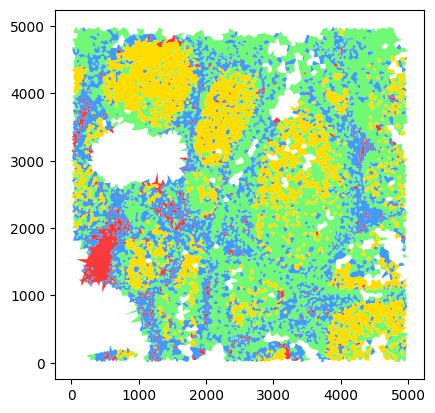

In [ ]:
# quick edits to visualize in notebook
import ast
voronoi['class_name'] = voronoi['classification'].apply(
        lambda x: ast.literal_eval(x).get('name') if isinstance(x, str) else x.get('name'))
voronoi['color'] = voronoi['class_name'].map(color_dict)
voronoi.plot(color=voronoi['color'])

In [136]:
#save to file
voronoi.to_file("outputs/voronoi_neighborhoods.geojson")

/Users/jnimoca/Jose_BI/1_Pipelines/openDVP/.pixi/envs/spatialdata/lib/python3.12/site-packages/pyogrio/geopandas.py:710: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(
